# Introduction to machine learning

In this notebook we will summarize the most important topics and methods in machine learning and basic neuroscience

## Mathematical equipment: Statistics groundwork

### Probability density
Let $X$ be a random variable, with $x \in X$ continually distributed. The variable is described by a probability density $\rho (x)$. Therefore the probabilities are given by the integral:
$$
p(a < x < b) = \int_a^b \mathrm{d}x\,\, \rho(x)
$$
Moreover $\rho(x)$ is normalized with:
$$
\int_{-\infty}^{\infty}\mathrm{dx} \, \rho(x) = 1
$$
For discrete distributions one has to take the sum instead of the integral.

### Expectation value, mean, variance, standard deviation and n-th moment
Let $X$ be a random variable, we define:
\begin{align*}
    & \mu = E(X) = \int_{-\infty}^{\infty}\mathrm{dx} \, \rho(x) x && \textcolor{gray}{\text{expectation value}}\\
    & \braket{x} = \sum_{i=1}^N x_i /N && \textcolor{gray}{\text{mean}}\\
    & \sigma = \sqrt{\int \mathrm{d}x \, (x - \mu)^2\cdot \rho(x)} && \textcolor{gray}{\text{standard deviation}}\\
    & V(X) = (\sigma)^2 = E(X^2) - E(X)^2 && \textcolor{gray}{\text{variance}}\\
    & \mu_n = \braket{X^n} && \textcolor{gray}{\text{n-th moment}}\\
\end{align*}
Here again the integral holds for continuous distributions. The mean consists of the average of a number of $N$ measured events. The law of great numbers states that for $N \rightarrow \infty$ independent draws and finite $\mu$ (and variance) the mean is equal to the expectation value. 

### Conditional probability
The probability for $X = x_i$ under the condition $Y = y_j$ is given by:
$$
p(x_i | y_j) = \frac{p(x_i \land y_j)}{p(y_j)}
$$
where $p(x_i \land y_j)$ is the probability that $x_i$ **and** $y_j$ occur. In general $p(x_i | y_j) \neq p(y_j | x_i)$.
Moreover the following theorems hold:
$$
\begin{align*}
&p(x_i) = \sum_j p(x_i \land y_j)\\
&p(x_i \lor y_j) = p(x_i) + p(y_j) - p(x_i \land y_j)\\
&p(x_i | y_j) = \frac{p(y_j | x_i) \cdot p(x_i)}{p(y_j)} \qquad \quad \textcolor{gray}{\text{Bayes theorem}}
\end{align*}
$$

### Covariance and correlation
Consider the random variables $A,B$. The correlation function $\mathrm{Corr}(AB) \in [-1,1]$ tells us how strongly these two variables are correlated:
\begin{align*}
& \mathrm{Cov}(AB) = \braket{\left( A - \braket{A} \right) \left( B - \braket{B} \right)} = \braket{AB} - \braket{A}\braket{B} && \textcolor{gray}{\text{covariance}}\\
&\mathrm{Corr}(AB) = \frac{\braket{\left( A - \braket{A} \right) \left( B - \braket{B} \right)}}{\sigma_A \sigma_B} = \frac{\braket{AB} - \braket{A}\braket{B}}{\sigma_A \sigma_B} && \textcolor{gray}{\text{correlation}}
\end{align*}
For $\mathrm{Corr}(AB) = 0$ the variables are called uncorrelated. Independence ($\braket{A + B} = \braket{A} + \braket{B}$) implies zero correlation, but zero correlation does not in general imply independence. The covariance is a dimensionful measure of correlation.

The correlation matrix of a set of variables $x_1,\dots, x_N$ is a $N\times N$ matrix defined by its matrix elements (same for covariance matrix) 
$$
C_{ij} = \mathrm{Corr}(x_i,x_j)
$$
Note that diagonal elements are always 1, since a variable always correlates with itself. The information of interest is situated on the off-diagonals, showing relations between different variables.

#### Example
This can easily be implemented in python via numpy. Consider a matrix $m$ with house prices, in the first line of the matrix, and floor spaces in meter squared in the second line. We want to check if these two quantities are correlated:

In [11]:
import numpy as np

# define matrix m
m = np.array([
    [100, 250, 400, 500, 600, 900, 1500, 1550],
    [20, 45, 40, 50, 60, 54, 90, 120]
           ])

# we construct an expectation value function from scratch here (vector input)
def E(x):
    return np.sum(x) / len(x)

## covariance function with arrays as input
def covariance(x,y):
    return E(x*y) - E(x)*E(y)

## and also explicitly the cov matrix
def covariance_matrix(x, y):
    return np.array([
        [covariance(x,x), covariance(x,y)],
        [covariance(y,x), covariance(y,y)]
    ])
    
x=m[0]
y=m[1]

print('We calculated the covariance to be Cov(m) = Cov(x,y) = ')
print(covariance_matrix(x,y))

# now we compare with the numpy function
print('We compare with the result of numpy: Cov(m) = Cov(x,y) = ')
print(np.cov(x,y, bias=True))

We calculated the covariance to be Cov(m) = Cov(x,y) = 
[[262500.        14071.875   ]
 [ 14071.875       857.609375]]
We compare with the result of numpy: Cov(m) = Cov(x,y) = 
[[262500.        14071.875   ]
 [ 14071.875       857.609375]]


So in fact we see that the two parameters are highly correlated. Also one can unse "numpy.corrcoef" to get the normalized covariance matrix via the components:
$$
R_{ij} = \frac{C_{ij}}{\sqrt{C_{ii} C_{jj}}}
$$.

In [12]:
np.corrcoef(m)

array([[1.        , 0.93786981],
       [0.93786981, 1.        ]])


## Important probability distribution

### Binomial distribution
The binomial distribution is a discrete distribution. It describes the distribution of stochastic experiments for which we only have two possible outcomes.


Let $n$ be the number of draws. The probability to get $k$ as outcome, with respective probability $p$ is:
$$
B(k|n,p) = \binom{n}{k} p^k (1-p)^{n-k} = \frac{n!}{(n-k)! \,k!}\, p^k (1-p)^{n-k}
$$
Expectation value: $E(X) = np$\
Second moment: $E(X^2) = np + (n-1)p^2n$\
Variance: $\sigma = np(1-p)$


### Poisson distribution
The Poisson distribution $P_\mu$ is also a discrete probability density. It is described by the expectation value $\mu$:
$$P_\mu (k) = \frac{\mu^k}{k!}e^{-\mu}$$
Expectation value: $\mathrm{E}(X) = \mu$\
Second moment: $\mathrm{E}(X^2) = \mu^2 + \mu$\
Variance $\sigma = \mu$\
The Poisson distribution arises from the Binomial distribution for $n \rightarrow \infty$ and $p \rightarrow 0$ with $\mu = np$.

### Gaussian distribution
The Gaussian distribution arises from the Binomial for large $n$ and $\mu \gg \sigma$. And is the solution of the differential equation:
$$
\frac{\mathrm{d} \rho}{ \mathrm{d}k} = \rho(k) \cdot \left( - \frac{x}{\sigma}\right)
$$
and therefore with $k = \mu + \sigma x$
$$
\frac{\mathrm{d} \rho}{ \mathrm{d}x} = -x \cdot \rho(x) 
$$
This ODE leads to:
$$
\begin{align*}
\rho(x) &= c \cdot \mathrm{e}^{-x^2/2}\\
& = \frac{1}{\sigma \sqrt{2\pi}} \cdot \exp(-(\mu - k )^2 / 2\sigma^2)
\end{align*}
$$


## Estimation

Consider a sample $\mathbf{x} = \{x_1, x_2, \ldots, x_N\}$ drawn independently from a random variable $X$ with probability distribution $P(x)$. Suppose we want to estimate a property $\theta$ of the underlying distribution, such as the expectation value $\theta = E(X)$. The **estimator** $\hat{\theta}$ is a function of the random sample and is therefore itself a random variable. For example,
$$
\hat{\theta} = \frac{1}{N}\sum_{i=1}^N X_i
$$
is the estimator of the expectation value. Once a particular sample $\mathbf{x}$ has been observed, the estimator takes on a specific value,
$$
\hat{\theta}(\mathbf{x}) = \frac{1}{N}\sum_{i=1}^N x_i,
$$
which is called the **estimate**. Thus, $\theta$ is the fixed (but potentially unknown) population property, $\hat{\theta}$ is the random estimator, and $\hat{\theta}(\mathbf{x})$ is the resulting estimate for a particular sample.

## Properties of estimators
- **consistency:** $E(\hat\theta) \to \theta$ and $V(\hat\theta) \to 0$ for $N \to \infty$
- **bias:** $b := E(\hat\theta) - \theta$
- **effciency:** $\varepsilon := \frac{V_\mathrm{min}}{V(\hat\theta)}$ where $V_\mathrm{min}$ is the minimal possible variance 

## Likelihood

The easiest way to understand **likelihood** is to distinguish it from probability. Suppose a random variable depends on an unknown parameter $\theta$ (in example the mean $\mu$). If $\theta$ is known and we ask how likely an observation $x$ is, we consider the **probability**
$$
P(x\mid\theta).
$$

In parameter estimation, we have the opposite situation: a sample $\mathbf{x}$ has been measure, while $\theta$ is unknown. We therefore treat $\mathbf{x}$ as fixed and ask:

> **Which value of $\theta$ makes the observed data most plausible?**

This is the **likelihood**:
$$
L(\mathbf{x};\theta) = P(\mathbf{x}\mid\theta).
$$

The notation emphasizes that $\mathbf{x}$ is fixed while $\theta$ is varied. For independent observations, the probability of observing all of them together is the product and thus also
$$
L(\mathbf{x};\theta)
=
\prod_{i=1}^N P(x_i\mid\theta).
$$

The **maximum likelihood estimator (MLE)** is the parameter value that maximizes this likelihood:
$$
\hat{\theta}_{\mathrm{ML}}
=
\arg\max_\theta L(\mathbf{x};\theta).
$$


### Example: Gaussian measurements

Suppose we measure a quantity $N$ times and obtain $x_1,\ldots,x_N$, where measurement $i$ has uncertainty $\sigma_i$. Assuming Gaussian errors with unknown mean $\mu$,
$$
P(x_i\mid\mu)
=
\frac{1}{\sqrt{2\pi}\sigma_i}
\exp\left(
-\frac{(x_i-\mu)^2}{2\sigma_i^2}
\right).
$$
For independent measurements we get
$$
L(\mathbf{x};\mu)
=
\prod_{i=1}^N P(x_i\mid\mu).
$$
It is easier to maximize the logarithm of the likelihood:
$$
\log L(\mathbf{x};\mu)
=
-\frac12
\sum_{i=1}^N
\frac{(x_i-\mu)^2}{\sigma_i^2}
+\mathrm{const}.
$$
Maximizing this is equivalent to minimizing the weighted squared deviations. Setting the derivative to zero gives
$$
\hat{\mu}_{\mathrm{ML}}
=
\frac{\displaystyle\sum_i x_i/\sigma_i^2}
{\displaystyle\sum_i 1/\sigma_i^2}.
$$

Thus, the maximum likelihood estimate is an **uncertainty-weighted average**: measurements with smaller $\sigma_i$ receive more weight because they are more precise.

In one sentence:

> **Likelihood asks: given the data I observed, which parameter value would have made these data most plausible?**


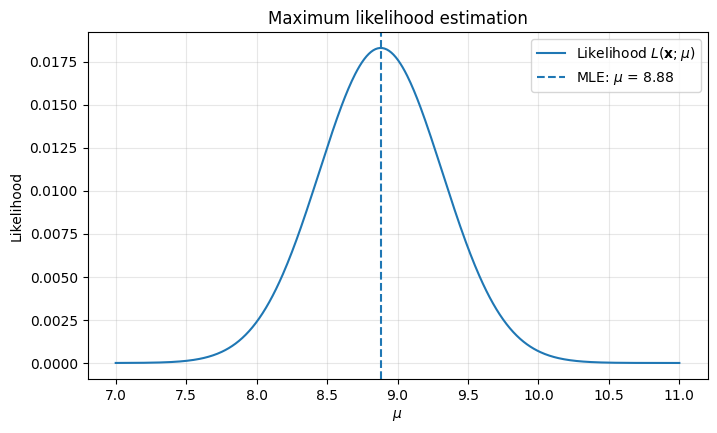

Maximum-likelihood estimate: mu = 8.88


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Observed measurements and their uncertainties
x = np.array([8.5, 10.0, 10.5])
sigma = np.array([0.5, 1.0, 2.0])
# We assume the data is Gauss distributed

# Try many possible values for the unknown mean
mu_values = np.linspace(7, 11, 500)

# Calculate the likelihood for each possible mu
likelihood = []

for mu in mu_values:
    # Probability of each measurement given this mu
    probabilities = (
        1 / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-(x - mu)**2 / (2 * sigma**2))
    )

    # Independent measurements -> multiply probabilities over x_i
    likelihood.append(np.prod(probabilities))

likelihood = np.array(likelihood)

# Find the maximum-likelihood estimate
mu_ml = mu_values[np.argmax(likelihood)]

# Plot likelihood as a function of mu
plt.figure(figsize=(8, 4.5))
plt.plot(mu_values, likelihood, label="Likelihood $L(\\mathbf{x};\\mu)$")
plt.axvline(mu_ml, linestyle="--",
            label=rf"MLE: $\mu$ = {mu_ml:.2f}")

plt.xlabel(r"$\mu$")
plt.ylabel("Likelihood")
plt.title("Maximum likelihood estimation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(rf"Maximum-likelihood estimate: mu = {mu_ml:.2f}")

## Implementation of Likelihood fit

We can use the Likelihood to fit a distribution to a dataset. The Likelihood Fit consists of the following steps:

- Choose a model $P(x\mid\theta)$ for how the data are distributed.
- Write the (log) likelihood for the observed data. 
- Maximize the likelihood (or log-likelihood) with respect to $\theta$. Note: when using scipy pass the negative log Likelihood, since scipy minimizes.
- The resulting $\hat{\theta}_{\mathrm{ML}}$ gives the fitted parameter values.

For multiple parameters, e.g. $\theta=(\theta_1,\theta_2)$, the same principle applies:
$$
\arg\max_{\theta_1,\theta_2}
L(\theta_1,\theta_2;\mathbf{x}).
$$
Note again here that in general one uses the logarithm of the Likelihood since products then become sums, which is easier to deal with.



### Example
Consider a sample $\mathbf{x} = \{x_1,x_2,\ldots,x_N\}$ drawn independently from a random variable $X$. We model the probability distribution with
$$
    P(x\mid\lambda_1,\lambda_2)
    =
    \frac{1}{2}\lambda_1 e^{-\lambda_1 x}
    +
    \frac{1}{2}\lambda_2 e^{-\lambda_2 x},
    \qquad x\geq 0,
$$
where the two parameters $\lambda_1>0$ and $\lambda_2>0$ are unknown. The likelihood of the observed sample is given by
$$
    L(\lambda_1,\lambda_2;\mathbf{x})
    =
    \prod_{i=1}^N
    P(x_i\mid\lambda_1,\lambda_2).
$$
It is more convenient to work with the log-likelihood,
$$
    \ell(\lambda_1,\lambda_2)
    =
    \log L(\lambda_1,\lambda_2;\mathbf{x}) = \sum_{i=1}^N
    \log
    \left(
    \frac{1}{2}\lambda_1 e^{-\lambda_1 x_i}
    +
    \frac{1}{2}\lambda_2 e^{-\lambda_2 x_i}
    \right).
$$
The maximum-likelihood estimates are obtained by maximizing the
log-likelihood with respect to both parameters,
$$
    (\hat{\lambda}_1,\hat{\lambda}_2)
    =
    \arg\max_{\lambda_1,\lambda_2}
    \ell(\lambda_1,\lambda_2).
$$
To find the maximum analytically, we set the derivatives of the
log-likelihood with respect to both parameters equal to zero.
For $\lambda_1$,
$$
    \frac{\partial\ell}{\partial\lambda_1}
    =
    \sum_{i=1}^N
    \frac{
    \frac{1}{2}e^{-\lambda_1x_i}
    \left(1-\lambda_1x_i\right)
    }{
    \frac{1}{2}\lambda_1e^{-\lambda_1x_i}
    +
    \frac{1}{2}\lambda_2e^{-\lambda_2x_i}
    }
    =0.
$$
Similarly, for $\lambda_2$,
$$
    \frac{\partial\ell}{\partial\lambda_2}
    =
    \sum_{i=1}^N
    \frac{
    \frac{1}{2}e^{-\lambda_2x_i}
    \left(1-\lambda_2x_i\right)
    }{
    \frac{1}{2}\lambda_1e^{-\lambda_1x_i}
    +
    \frac{1}{2}\lambda_2e^{-\lambda_2x_i}
    }
    =0.
$$
Unlike the single-exponential case, these two equations cannot in
general be solved explicitly for $\hat{\lambda}_1$ and
$\hat{\lambda}_2$. The maximum-likelihood estimates therefore have to
be determined numerically.
The fitted parameters are consequently given by
$$
    (\hat{\lambda}_1,\hat{\lambda}_2)
    =
    \arg\max_{\lambda_1>0,\lambda_2>0}
    \sum_{i=1}^N
    \log
    \left(
    \frac{1}{2}\lambda_1 e^{-\lambda_1 x_i}
    +
    \frac{1}{2}\lambda_2 e^{-\lambda_2 x_i}
    \right).
$$
Once the fitted parameters have been obtained, the fitted probability
distribution is
$$
    P(x\mid\hat{\lambda}_1,\hat{\lambda}_2)
    =
    \frac{1}{2}\hat{\lambda}_1
    e^{-\hat{\lambda}_1x}
    +
    \frac{1}{2}\hat{\lambda}_2
    e^{-\hat{\lambda}_2x}.
$$

The fitted distribution can then be compared with the observed data
using a histogram of the sample.

Note that the model is symmetric under the exchange
$
\lambda_1 \leftrightarrow \lambda_2.
$
Therefore, the parameter pairs
$
(\hat{\lambda}_1,\hat{\lambda}_2)
\,\text{and}\,
(\hat{\lambda}_2,\hat{\lambda}_1)
$
describe the same probability distribution.

True parameters:
lambda1 = 0.500
lambda2 = 2.000

Fitted parameters:
lambda1 = 0.481
lambda2 = 2.019


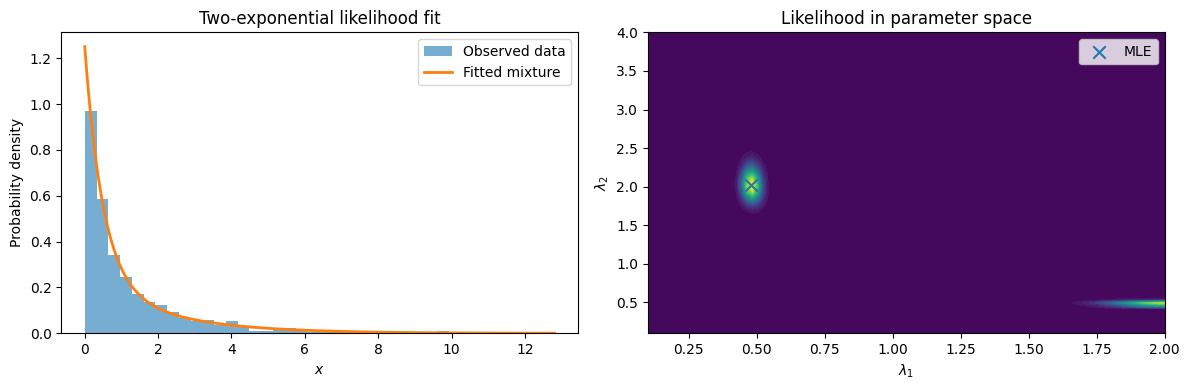

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ------------------------------------------------------------
# 1. Generate (recreatable) example data
# ------------------------------------------------------------
np.random.seed(42)
N = 1000
# True parameters
lambda1_true = 0.5
lambda2_true = 2.0

# Generate data from a 50/50 mixture of two exponential distributions
components = np.random.rand(N) < 0.5  # boolean list
x = np.where(
    components,
    np.random.exponential(1 / lambda1_true, N),
    np.random.exponential(1 / lambda2_true, N)
)


# ------------------------------------------------------------
# 2. Define the two-component exponential PDF 
# ------------------------------------------------------------
def pdf(x, lambda1, lambda2):
    return (
        0.5 * lambda1 * np.exp(-lambda1 * x)
        + 0.5 * lambda2 * np.exp(-lambda2 * x)
    )


# ------------------------------------------------------------
# 3. Define the negative log-likelihood
# ------------------------------------------------------------
def negative_log_likelihood(params):
    lambda1, lambda2 = params
    # Parameters must be positive
    if lambda1 <= 0 or lambda2 <= 0:
        return np.inf
    probabilities = pdf(x, lambda1, lambda2)
    # Numerical safety
    probabilities = np.maximum(probabilities, 1e-300)
    log_likelihood = np.sum(np.log(probabilities))
    # scipy minimizes, so return the negative log-likelihood
    return -log_likelihood


# ------------------------------------------------------------
# 4. Fit lambda1 and lambda2
# ------------------------------------------------------------
initial_guess = [0.4, 1.5]

result = minimize(
    negative_log_likelihood,
    initial_guess,
    method="Nelder-Mead"
)

lambda1_fit, lambda2_fit = result.x

print("True parameters:")
print(f"lambda1 = {lambda1_true:.3f}")
print(f"lambda2 = {lambda2_true:.3f}")

print("\nFitted parameters:")
print(f"lambda1 = {lambda1_fit:.3f}")
print(f"lambda2 = {lambda2_fit:.3f}")


# ------------------------------------------------------------
# 5. Calculate the fitted distribution
# ------------------------------------------------------------
x_plot = np.linspace(0, np.max(x), 1000)
y_fit = pdf(
    x_plot,
    lambda1_fit,
    lambda2_fit
)


# ------------------------------------------------------------
# 6. Plot the data and fitted distribution
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: data + fitted distribution ---
axes[0].hist(
    x,
    bins=40,
    density=True,
    alpha=0.6,
    label="Observed data"
)

axes[0].plot(
    x_plot,
    y_fit,
    linewidth=2,
    label="Fitted mixture"
)

axes[0].set_xlabel("$x$")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Two-exponential likelihood fit")
axes[0].legend()


# ------------------------------------------------------------
# 7. Visualize the likelihood in parameter space
# ------------------------------------------------------------
lambda1_values = np.linspace(0.1, 2.0, 100)
lambda2_values = np.linspace(0.1, 4.0, 100)

L = np.zeros(
    (len(lambda2_values), len(lambda1_values))
)

for i, l1 in enumerate(lambda1_values):
    for j, l2 in enumerate(lambda2_values):

        probabilities = pdf(x, l1, l2)
        probabilities = np.maximum(probabilities, 1e-300)

        # Log-likelihood is used for numerical stability
        L[j, i] = np.sum(np.log(probabilities))

# Convert log-likelihood to a relative likelihood
L_relative = np.exp(L - np.max(L))

# Plot likelihood surface
im = axes[1].contourf(
    lambda1_values,
    lambda2_values,
    L_relative,   # We could also just use L for plotting but the relative value has more contrast (more visible maximum/minimum)
    levels=30
)

axes[1].scatter(
    lambda1_fit,
    lambda2_fit,
    s=80,
    marker="x",
    label="MLE"
)

axes[1].set_xlabel("$\\lambda_1$")
axes[1].set_ylabel("$\\lambda_2$")
axes[1].set_title("Likelihood in parameter space")
axes[1].legend()

plt.tight_layout()
plt.show()

## Chi-squared fits

An alternative fitting method is discussed in the following. The basic idea of a $\chi^2$ fit is very intuitive: Suppose we have measured values
$
y_1,y_2,\ldots,y_N
$
at known positions
$
x_1,x_2,\ldots,x_N,
$
and we have a model
$
f(x;\theta).
$
For a given parameter value $\theta$, the model predicts
$
f_i = f(x_i;\theta).
$
The difference between the observation and the model prediction is the **residual**
$$
r_i = y_i-f_i.
$$
If each measurement has an uncertainty $\sigma_i$, we can express the residual in units of its uncertainty:
$
\frac{y_i-f_i}{\sigma_i}.
$
The $\chi^2$ value is defined as
$$
\boxed{
\chi^2(\theta)
=
\sum_{i=1}^N
\frac{\left[y_i-f(x_i;\theta)\right]^2}{\sigma_i^2}
}
$$
Thus, $\chi^2$ measures how far the data are from the model, taking the uncertainties of the measurements into account, where large deviations are penalized strongly.
The best-fit parameters are obtained by minimizing $\chi^2$. In fact, under the assumption that the measurement errors are independent and Gaussian, minimizing $\chi^2$ is equivalent to maximizing the likelihood. 



### $\chi^2$ for histogram data

Suppose instead that we have a histogram with observed bin contents
$
O_1,O_2,\ldots,O_B.
$
Our model predicts an expected number of events in each bin,
$
E_1,E_2,\ldots,E_B.
$
A simple Pearson $\chi^2$ statistic is
$$
\boxed{
\chi^2
=
\sum_{i=1}^B
\frac{(O_i-E_i)^2}{E_i}
}
$$

where the denominator represents the expected variance for a Poisson
count when
$$
\operatorname{Var}(O_i)\approx E_i.
$$

More generally, if the uncertainty of a bin is $\sigma_i$, we can write

$$
\chi^2
=
\sum_{i=1}^B
\frac{(O_i-E_i)^2}{\sigma_i^2}.
$$

## Goodness of fit

After fitting a model we still want to know whether the fitted model provides a good description
of the observed data. This is a different question from finding the best-fit parameters.

- **Parameter estimation:** Which values of $\theta$ describe the data best?
- **Goodness of fit:** Is the resulting model actually compatible with the data?

There are several ways to quantify the goodness of a fit. The appropriate
method depends on the type of data and on what assumptions we are willing
to make.




### Reduced $\chi^2$

A commonly used quantity used for a measure of goodness is the **reduced chi-squared**
$$
\boxed{
\chi^2_\nu
=
\frac{\chi^2}{\nu},
}
$$
where $\nu$ is the number of degrees of freedom. If we have $N$ data points and fit $p$ independent parameters,
$$
\nu=N-p.
$$
Roughly speaking:

- $\chi^2_\nu\approx1$: the deviations are of the expected size.
- $\chi^2_\nu\gg1$: the data deviate from the model more than expected.
- $\chi^2_\nu\ll1$: the deviations are smaller than expected (errors to large, correlations in data or overfitting).

However, $\chi^2_\nu$ should not be interpreted as an absolute goodness-of-fit
measure by itself. Its interpretation depends on the uncertainty model,
the number of degrees of freedom, and the assumptions underlying the
$\chi^2$ statistic.


## Implementation of chi squared fit

Best-fit parameters:
A     = 1.986
omega = 1.312
phi   = 0.339
c     = 0.537

chi^2             = 28.42
degrees of freedom = 46
reduced chi^2      = 0.62


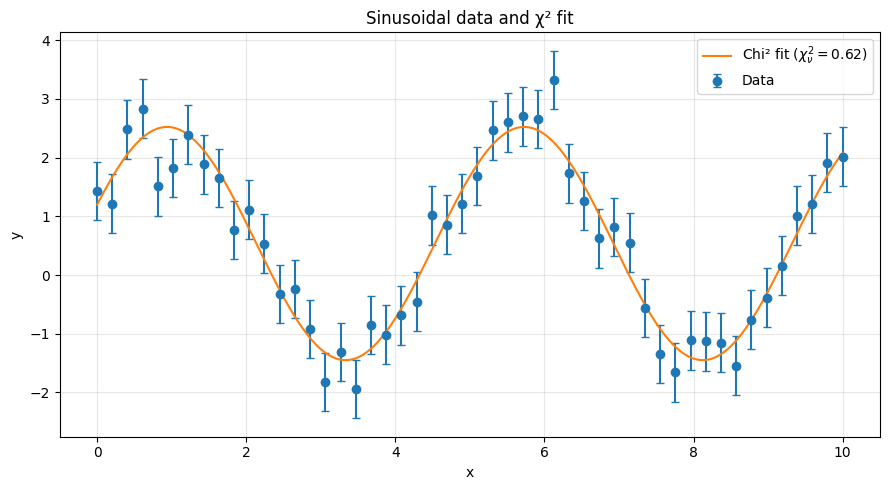

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# -----------------------------
# 1. Create synthetic data
# -----------------------------
rng = np.random.default_rng(42)  # Reproducible random data
N = 50
x = np.linspace(0, 10, N)

A_true = 2.0
omega_true = 1.3
phi_true = 0.4
c_true = 0.5
sigma = 0.5

y_true = A_true * np.sin(omega_true * x + phi_true) + c_true  # true function
y = y_true + rng.normal(0, sigma, N)   # measured sample

# -----------------------------
# 2. Define the sinusoidal model
# -----------------------------
def model(x, A, omega, phi, c):
    return A * np.sin(omega * x + phi) + c

# -----------------------------
# 3. Chi-squared fit
# -----------------------------
# We minimize:
# chi^2 = sum_i [(y_i - model_i) / sigma_i]^2

def residuals(params):
    A, omega, phi, c = params
    return (y - model(x, A, omega, phi, c)) / sigma

# Initial guess
p0 = [1.5, 1.0, 0.0, 0.0]

# Bounds help avoid the trivial low-frequency solution
result = least_squares(
    residuals,
    p0,
    bounds=([0, 0.5, -2*np.pi, -5],
            [5, 2.0,  2*np.pi,  5])
)

A_fit, omega_fit, phi_fit, c_fit = result.x

# -----------------------------
# 4. Calculate chi^2 and reduced chi^2
# -----------------------------
y_fit = model(x, A_fit, omega_fit, phi_fit, c_fit)

chi2 = np.sum(((y - y_fit) / sigma) ** 2)

p = 4                 # A, omega, phi, c
dof = N - p           # degrees of freedom
reduced_chi2 = chi2 / dof

print(f"Best-fit parameters:")
print(f"A     = {A_fit:.3f}")
print(f"omega = {omega_fit:.3f}")
print(f"phi   = {phi_fit:.3f}")
print(f"c     = {c_fit:.3f}")
print()
print(f"chi^2             = {chi2:.2f}")
print(f"degrees of freedom = {dof}")
print(f"reduced chi^2      = {reduced_chi2:.2f}")

# -----------------------------
# 5. Plot
# -----------------------------
x_smooth = np.linspace(x.min(), x.max(), 500)
y_smooth = model(x_smooth, A_fit, omega_fit, phi_fit, c_fit)

plt.figure(figsize=(9, 5))

plt.errorbar(
    x, y,
    yerr=sigma,
    fmt="o",
    capsize=3,
    label="Data"
)

plt.plot(
    x_smooth,
    y_smooth,
    label=rf"Chi² fit ($\chi^2_\nu={reduced_chi2:.2f}$)"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Sinusoidal data and χ² fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Minimization algorithm : Gradient descent optimization

Most deep learning algorithms involve optimization of some sort. Optimization
refers to the task of either minimizing or maximizing some function $f(x)$ by altering
$x$. We usually phrase most optimization problems in terms of minimizing $f(x)$. Maximization may be accomplished via a minimization algorithm by minimizing $-f(x)$. The function we want to minimize or maximize is called the objective function or criterion. When we are minimizing it, we may also call it the cost
function, loss function, or error function [Deep Learning Ian Goodfellow, S. 82].

We can decrease $f$ by moving in the direction of the negative gradient.
This is known as the method of steepest descent or gradient descent. A new point is then given by:
$$
x' = x - \eta \nabla_x f(x)
$$
where $\eta$ is the learning rate (step size) [Deep Learning Ian Goodfellow, S. 85,86].

# Machine learning algorithm: linear regression

Linear regression is a machine learning algorithm, that solves a regression prolem, where the input is connected linearly to the output. 

Consider an input matrix $\textbf{x} \in \mathbb{R}^{n\times p}$. The input consists of $p$ $\textbf{features}$ and each feature has $n$ input values. The output $\textbf{y} \in \mathbb{R}^p$ is then given by: 

$$
\textbf{y} = \textbf{x} \textbf{w} + \textbf{b}
$$
where $\textbf{w} \in \mathbb{R}^p$ is a vector of parameters and $\textbf{b}$ the bias or intercept. We can think of $\textbf{w}$ as a set of $\textbf{weights}$ that determine how each feature affects the output. If a feature receives a positive weight $w_i$, then increasing the value of that feature increases the value of our prediction $\hat{y}$. 

In a more sophisticate model one can absorb the bias in $\textbf{x}$ by adding a row of ones:
$$
\textbf{X} = \begin{pmatrix}
                1 & x_1^1 & \dots & x_1^p\\
                \vdots & \vdots & \ddots & \vdots\\
                1 & x_n^1 & \dots & x_n^p\\
             \end{pmatrix}
$$
If we define a new weight vector $\textbf{W} \in \mathbb{R}^{p+1}$, where $w_0$ corresponds to the bias, linear regression model becomes
$$
\textbf{y} = \textbf{X} \textbf{W}.
$$
Fitting a linear model to a given data set usually requires estimating the weights such that the error term $\textbf{E} = \textbf{y} − \textbf{X} \textbf{W}$ is minimized. For example, it is common to use the sum of squared errors 
$$
SSE = |\textbf{E}|^2 = |\textbf{y} − \textbf{X} \textbf{W}|^2
$$
as a measure of $\textbf{E}$ for minimization. 

## Implement linear regression for 1 feature

We consider the case where we only have one feature. We will persude the following steps:
- Compute linear regression using scikit-learn
- Examine the error curve 
- Compute linear regression "by hand" using pseudo matrix inverse
- Examine the error curve
- Compare both methods

In [16]:
#import packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#set plot specifications
def plot_secifications(xlabel, ylabel):
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

#define the data
def generate_data(true_slope):
    x = np.linspace(0,30,100)
    y = true_slope * x + np.random.randint(20, size=100)
    
    #reshape data
    x = x.reshape(-1,1)
    y = y.reshape(-1,1)
    return x,y

True Intercept: 0
Intercept: [11.12277228]
True Slope: 3.141592653589793
Slope: [3.02874117]


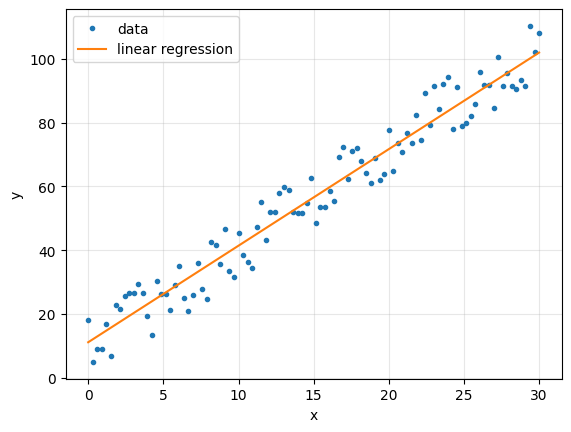

In [17]:
#generate data
true_slope = np.pi
x,y = generate_data(true_slope)

#create a LinearRegression object
lr = LinearRegression()

# fit the model to the data
lr.fit(x, y)

# print the intercept and slope of the fitted line
print('True Intercept:', 0)
print('Intercept:', lr.intercept_)
print('True Slope:', true_slope)
print('Slope:', lr.coef_[0])

#plot the data and fit
plt.plot(x, y, '.', label='data')
plt.plot(x, lr.coef_[0] * x + lr.intercept_, label='linear regression')
plot_secifications('x', 'y')

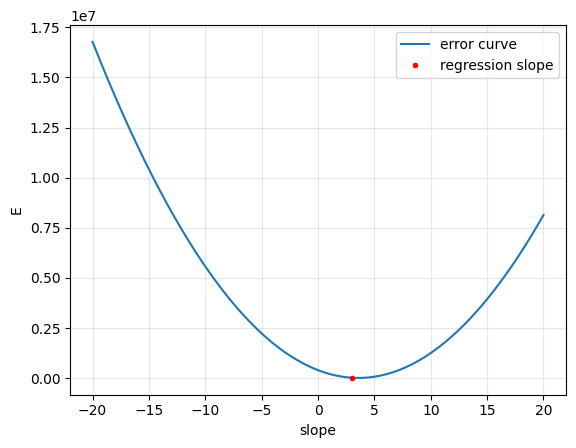

In [18]:
#examine error 
def E(x, y, slope_array):
    error = []
    for slope in slope_array:
        error.append(np.sum((y - x*slope)**2))
    return np.array(error)

def plot_error_curve():
    #print error curve
    slope_array = np.linspace(-20,20,1000)
    plt.plot(slope_array, E(x, y, slope_array), label='error curve')
    #plot the slope from linear regression
    plt.plot(lr.coef_[0], np.sum((y - x*lr.coef_[0])**2), '.', color='red', label='regression slope')
    plot_secifications('slope', 'E')
    
plot_error_curve()

We can see that the regression was sucessfull. The slope lies in the minimum of the error function, that we wanted to minimize.

We now perform the same steps using a by-hand minimization.

True Intercept: 0
Intercept: [10.45920792]
True Slope: 3.141592653589793
Slope: [3.09897879]


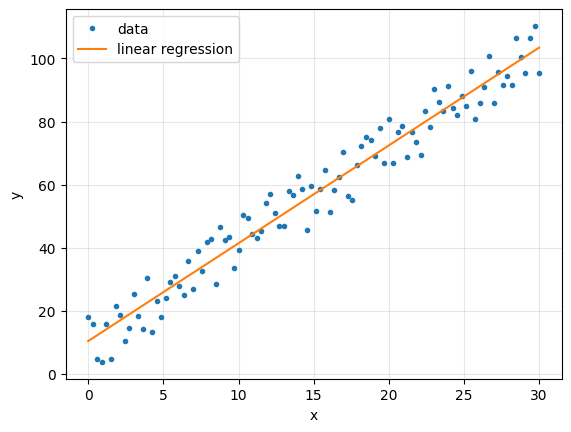

In [19]:
#generate data
true_slope = np.pi
x,y = generate_data(true_slope)

# add a column of ones to X for the intercept term
X_aug = np.hstack((np.ones((x.shape[0], 1)), x))

# compute the weights using the pseudo-inverse method
w = np.linalg.inv(X_aug.T.dot(X_aug)).dot(X_aug.T).dot(y)

# print the intercept and slope of the fitted line
print('True Intercept:', 0)
print('Intercept:', w[0])
print('True Slope:', true_slope)
print('Slope:', w[1])

#plot the data and fit
plt.plot(x, y, '.', label='data')
plt.plot(x, w[1] * x + w[0], label='linear regression')
plot_secifications('x', 'y')

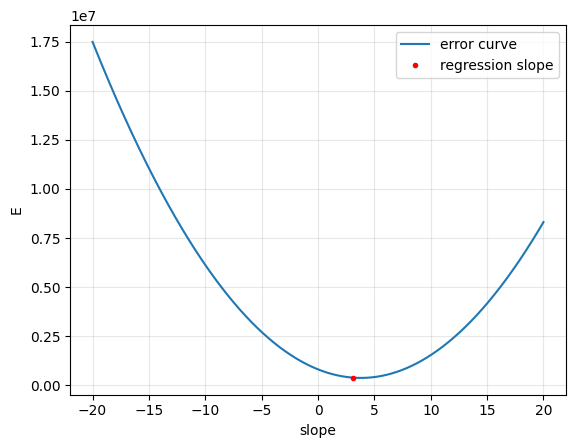

In [20]:
#examine error 
def E(x, y, slope_array):
    error = []
    for slope in slope_array:
        error.append(np.sum((y - x*slope)**2))
    return np.array(error)

def plot_error_curve():
    #print error curve
    slope_array = np.linspace(-20,20,1000)
    plt.plot(slope_array, E(X_aug, y, slope_array), label='error curve')
    #plot the slope from linear regression
    plt.plot(w[1], np.sum((y - w[1])**2), '.', color='red', label='regression slope')
    plot_secifications('slope', 'E')
    
plot_error_curve()

The difference between the two methods lies in the implementation details. Scikit-learn's LinearRegression uses the method of least squares, which is a common approach for solving linear regression problems. It involves setting up and solving a system of linear equations to obtain the optimal weights.

The pseudo-inverse method, on the other hand, is a matrix-based approach that involves computing the Moore-Penrose pseudo-inverse of the input matrix and using it to solve for the weights. This method is particularly useful when the input matrix is not full rank, meaning it does not have an inverse. In such cases, the pseudo-inverse provides a way to obtain a solution that minimizes the sum of squared errors.

Both methods will produce the same result for a given linear regression problem, but the pseudo-inverse method can be more computationally efficient in some cases, particularly when the input matrix is not full rank. Scikit-learn's LinearRegression is a more general method that can be applied to a variety of linear regression problems, and it also includes additional features such as regularization options and methods for handling categorical variables [chatGPT].

## Cost Functions

### Definition

In the context of supervised learning, a **cost function** (or loss function) $J(\theta)$ measures how far the predictions $\hat{y}$ of a model, parameterized by $\theta$, deviate from the true targets $y$. Training a machine learning model consists of finding parameters $\theta^*$ that minimize this cost function using an optimization procedure such as gradient descent:

$$
\theta^* = \arg\min_\theta J(\theta)
$$

The choice of cost function depends on the type of task (regression or classification) and is closely tied to a probabilistic interpretation of the model via **maximum likelihood estimation (MLE)**.

### Mean Squared Error (MSE)

For regression tasks, the most common cost function is the mean squared error, which generalizes the sum of squared errors introduced for linear regression by averaging over the number of samples $n$:

$$
\text{MSE}(\textbf{W}) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \lVert \textbf{y} - \textbf{X}\textbf{W} \rVert^2
$$

Minimizing the MSE is equivalent to maximizing the likelihood of the data under the assumption that the noise on $y$ is Gaussian with fixed variance.

### Cross-Entropy Loss

For classification tasks, the model output is typically interpreted as a probability distribution over classes, and the **cross-entropy loss** is used instead of MSE.

**Binary classification.** If $\hat{y} \in (0,1)$ is the predicted probability of the positive class (e.g. obtained via a sigmoid output), the binary cross-entropy (or log loss) is:

$$
J(\textbf{W}) = -\frac{1}{n}\sum_{i=1}^{n} \Big[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \Big]
$$

**Multi-class classification.** If $\hat{y}_i \in \mathbb{R}^K$ is a probability vector over $K$ classes (obtained via a softmax output) and $y_i \in \mathbb{R}^K$ is the one-hot encoded true label, the categorical cross-entropy is:

$$
J(\textbf{W}) = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{i,k} \log(\hat{y}_{i,k})
$$

Cross-entropy penalizes confident wrong predictions much more heavily than MSE would, which makes it better suited to classification, and it corresponds to maximizing the likelihood of the data under a Bernoulli (binary case) or categorical (multi-class case) distribution.

## Basics of Neural Networks

### From Linear Regression to Neural Networks

A single artificial neuron generalizes the linear regression model by applying a nonlinear **activation function** $\sigma$ to the linear combination of inputs:

$$
a = \sigma(\textbf{x}^\top \textbf{w} + b)
$$

Without $\sigma$, stacking several linear layers would still collapse to a single linear transformation. The activation function introduces the nonlinearity that allows neural networks to approximate complex, non-linear functions.

Common activation functions:

| Name | Formula | Notes |
|---|---|---|
| Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ | Squashes to $(0,1)$, used for binary outputs |
| Tanh | $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ | Squashes to $(-1,1)$, zero-centered |
| ReLU | $\text{ReLU}(z) = \max(0, z)$ | Default choice for hidden layers, cheap and mitigates vanishing gradients |
| Softmax | $\text{softmax}(z)_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$ | Used in output layer for multi-class classification |

### Forward Propagation

A feedforward neural network with $L$ layers computes its output by successively applying affine transformations and activations:

$$
\textbf{a}^{(l)} = \sigma^{(l)}\big(\textbf{W}^{(l)} \textbf{a}^{(l-1)} + \textbf{b}^{(l)}\big), \qquad l = 1, \dots, L
$$

with $\textbf{a}^{(0)} = \textbf{x}$ the input and $\hat{\textbf{y}} = \textbf{a}^{(L)}$ the output.



## Backpropagation

Training the network means finding the weights and biases in every layer that minimize the cost function $J(\textbf{W})$. Gradient descent tells us how to update each parameter:

$$
w' = w - \eta \frac{\partial J}{\partial w}
$$

but to use this rule we first need to compute $\frac{\partial J}{\partial w}$ for *every single weight in every layer*. **Backpropagation** is simply the algorithm that computes all of these gradients efficiently.

### The core idea

The network is a chain of functions: the input passes through layer 1, then layer 2, and so on, until it produces the output $\hat{y}$, which is compared to $y$ by the cost function $J$. Because of this chain structure, we can use the **chain rule** from calculus to compute how a change in any weight affects $J$.

The key insight is the *direction* in which we compute things:

- **Forward pass:** the input flows forward through the layers, from layer $1$ to layer $L$, to produce $\hat{y}$ and the cost $J$.
- **Backward pass:** the gradient information flows backward, from layer $L$ back to layer $1$. We start by asking "how much does the cost change if the *output* changes?", and then propagate that sensitivity backward, layer by layer, until we know "how much does the cost change if *this particular weight* changes?".

This backward flow is where the name "backpropagation" comes from: we are propagating the error signal backward through the network.

### Why not compute each gradient from scratch?

A naive approach would be to compute $\frac{\partial J}{\partial w}$ independently for each weight, recomputing the full forward pass each time. For a network with millions of weights, this would be extremely wasteful.

Backpropagation avoids this by reusing intermediate results. Consider two consecutive layers. The chain rule tells us:

$$
\frac{\partial J}{\partial \textbf{W}^{(l)}} = \frac{\partial J}{\partial \textbf{a}^{(l)}} \cdot \frac{\partial \textbf{a}^{(l)}}{\partial \textbf{W}^{(l)}}
$$

The term $\frac{\partial J}{\partial \textbf{a}^{(l)}}$ (how sensitive the cost is to layer $l$'s output) does **not** need to be recomputed for every weight in that layer, it is computed once per layer and then reused for all weights feeding into it. Moreover, this term for layer $l$ is itself computed from the corresponding term of layer $l+1$:

$$
\frac{\partial J}{\partial \textbf{a}^{(l)}} = \frac{\partial J}{\partial \textbf{a}^{(l+1)}} \cdot \frac{\partial \textbf{a}^{(l+1)}}{\partial \textbf{a}^{(l)}}
$$

So instead of recomputing everything from scratch for each weight, we compute one "error signal" per layer, starting at the output and working backward, and reuse it for every weight in that layer. This is what makes backpropagation efficient: each intermediate derivative is computed once and shared.

### The algorithm in three steps

1. **Forward pass:** compute $\textbf{a}^{(1)}, \textbf{a}^{(2)}, \dots, \textbf{a}^{(L)} = \hat{\textbf{y}}$, and finally the cost $J$. Store the intermediate values $\textbf{a}^{(l)}$, since they are needed in the next step.
2. **Backward pass:** starting from the output layer, compute the error signal $\frac{\partial J}{\partial \textbf{a}^{(l)}}$ for each layer, moving from $l = L$ down to $l = 1$, each time reusing the error signal from the layer above.
3. **Weight update:** use the error signal of each layer to compute $\frac{\partial J}{\partial \textbf{W}^{(l)}}$ and $\frac{\partial J}{\partial \textbf{b}^{(l)}}$, then update the parameters with gradient descent: $\textbf{W}^{(l)\prime} = \textbf{W}^{(l)} - \eta \frac{\partial J}{\partial \textbf{W}^{(l)}}$.

In practice you never need to implement these derivatives by hand. Frameworks like TensorFlow and PyTorch build a computational graph of every operation performed during the forward pass, and use **automatic differentiation** to apply the chain rule automatically and compute all gradients in the backward pass. As a user, you only need to define the forward pass (the architecture) and the cost function. Calling `.backward()` (PyTorch) or letting `model.fit` handle it internally (Keras) triggers the full backpropagation algorithm described above.



### Overfitting and Generalization

A model that fits the training data too closely and fails to generalize to unseen data is said to **overfit**. To assess this, data is usually split into:

- a **training set**, used to fit the parameters $\textbf{W}$,
- a **validation set**, used to tune hyperparameters (learning rate, network architecture, regularization strength) and monitor overfitting during training,
- a **test set**, used only once, to report the final performance of the model.

Common techniques to reduce overfitting include **regularization** (e.g. adding a penalty term such as $\lambda \lVert \textbf{W} \rVert^2$ to the cost function), **dropout** (randomly deactivating neurons during training), and **early stopping** (stopping training once validation performance stops improving).


## Training Neural Networks with TensorFlow / PyTorch

Modern deep learning frameworks such as **TensorFlow** (with the Keras API) and **PyTorch** remove the need to implement backpropagation manually. They provide automatic differentiation, GPU acceleration, and pre-built layers, optimizers, and cost functions. Both frameworks follow the same conceptual training loop:

1. **Define the model**: specify the sequence of layers (architecture).
2. **Define the cost function**: e.g. MSE for regression, cross-entropy for classification.
3. **Define the optimizer**: an algorithm that updates the weights using the gradients, e.g. stochastic gradient descent (SGD) or Adam, which is an adaptive variant combining momentum and per-parameter learning rates.
4. **Loop over the data**: for each batch: compute the forward pass, compute the loss, compute the gradients (backpropagation), update the weights.
5. **Validate**: periodically evaluate on the validation set to monitor generalization.



## TensorFlow / Keras example

```python
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(p,)),
    tf.keras.layers.Dense(1)  # linear output for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

model.fit(X_train, y_train, validation_data=(X_val, y_val),
          epochs=50, batch_size=32)
```

## PyTorch example

```python
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(p, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(50):
    optimizer.zero_grad()          # reset gradients
    y_hat = model(X_train)         # forward pass
    loss = criterion(y_hat, y_train)
    loss.backward()                # backpropagation (autograd)
    optimizer.step()               # gradient descent update
```

The key difference is the level of abstraction: Keras hides the training loop behind `model.fit`, while PyTorch exposes it explicitly (`zero_grad`, `backward`, `step`), which mirrors the gradient descent update rule $x' = x - \eta \nabla_x f(x)$ applied to every parameter tensor in the model.

Final predictions (should be close to [0, 1, 1, 0]):
[0.0879679  0.99895704 0.9985684  0.0879679 ]


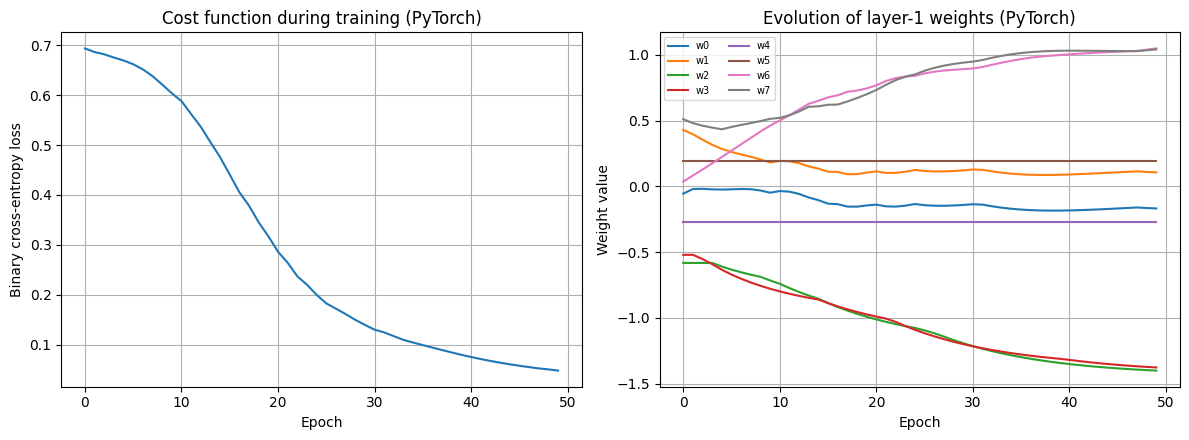

In [23]:
"""
Simple 3-layer neural network trained on the XOR problem with PyTorch.

XOR is not linearly separable, so a plain "fit" (like linear regression)
cannot solve it. A network with a hidden layer and a nonlinear activation
can, which is why this is a good minimal example of what neural network
*training* can do beyond fitting.
"""

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)  # for reproducibility

# ---------------------------------------------------------------------------
# 1. Data: the XOR truth table
# ---------------------------------------------------------------------------
X = torch.tensor([[0., 0.],
                   [0., 1.],
                   [1., 0.],
                   [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

# ---------------------------------------------------------------------------
# 2. Model: 3 layers -> input(2) -> hidden(8) -> hidden(8) -> output(1)
#    We use ReLU after the two hidden layers and a sigmoid on the output,
#    since this is a binary classification task.
# ---------------------------------------------------------------------------
model = nn.Sequential(
    nn.Linear(2, 8),   # layer 1: input -> hidden
    nn.ReLU(),
    nn.Linear(8, 8),   # layer 2: hidden -> hidden
    nn.ReLU(),
    nn.Linear(8, 1),   # layer 3: hidden -> output
    nn.Sigmoid()
)

criterion = nn.BCELoss()                                 # binary cross-entropy cost
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)  # Adam optimizer (gradient descent variant)

# ---------------------------------------------------------------------------
# 3. Training loop, recording the weights of layer 1 after every epoch
#    so we can visualize how gradient descent moves them over time.
# ---------------------------------------------------------------------------
n_epochs = 50
weight_history = []  # will store a snapshot of layer-1 weights each epoch
loss_history = []

layer1 = model[0]  # the first nn.Linear layer, whose weights we track

for epoch in range(n_epochs):
    optimizer.zero_grad()          # reset gradients from the previous step
    y_hat = model(X)               # forward pass
    loss = criterion(y_hat, y)     # compute the cost J
    loss.backward()                # backpropagation: compute dJ/dW for every layer
    optimizer.step()               # gradient descent update: W' = W - eta * dJ/dW

    # record a copy of the current layer-1 weights (flattened, 16 numbers: 8x2)
    weight_history.append(layer1.weight.detach().clone().flatten().numpy())
    loss_history.append(loss.item())

weight_history = np.array(weight_history)  # shape (n_epochs, 16)

# ---------------------------------------------------------------------------
# 4. Check the final predictions
# ---------------------------------------------------------------------------
with torch.no_grad():
    preds = model(X)
print("Final predictions (should be close to [0, 1, 1, 0]):")
print(preds.flatten().numpy())

# ---------------------------------------------------------------------------
# 5. Plot: cost curve + evolution of a handful of layer-1 weights
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(loss_history)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy loss")
axes[0].set_title("Cost function during training (PyTorch)")
axes[0].grid()

# plot the first 8 of the 16 layer-1 weights over training
for i in range(8):
    axes[1].plot(weight_history[:, i], label=f"w{i}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weight value")
axes[1].set_title("Evolution of layer-1 weights (PyTorch)")
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid()

plt.tight_layout()
plt.show()


## Convolutional Neural Networks (CNNs)

### Motivation

For high-dimensional, structured inputs such as images, a fully connected layer is impractical: an image of size $224 \times 224 \times 3$ has over $150{,}000$ input values, so a single dense layer with $64$ neurons would already require millions of weights, ignoring the spatial structure of the image entirely. **Convolutional Neural Networks (CNNs)** exploit two key properties of image data  (**local correlation** and **translation invariance**) by replacing generic matrix multiplication with the **convolution operation** in at least one layer. 

### The Convolution Operation

Given an input feature map $\textbf{I}$ and a small filter (kernel) $\textbf{K} \in \mathbb{R}^{k \times k}$, the 2D discrete convolution produces an output feature map $\textbf{S}$:

$$
S(i,j) = (\textbf{I} * \textbf{K})(i,j) = \sum_m \sum_n I(i+m, j+n) \, K(m,n)
$$

The filter $\textbf{K}$ slides across the input and computes a weighted sum at every position, producing a **feature map** that highlights where a particular local pattern (e.g. an edge, a texture) occurs in the input. Unlike a fully connected layer, the same filter (i.e. the same weights) is reused at every spatial location, this is called **parameter sharing**, and it drastically reduces the number of trainable parameters compared to a dense layer while making the detector translation-invariant.

### Padding and Stride

- **Padding** adds extra pixels (usually zeros) around the border of the input so the output feature map does not shrink after each convolution ("same" padding), or is left to shrink naturally ("valid" padding).
- **Stride** $s$ is the step size with which the filter moves across the input. A stride greater than $1$ downsamples the output feature map.

For an input of size $n \times n$, a filter of size $k \times k$, padding $p$, and stride $s$, the output size is:

$$
\left\lfloor \frac{n + 2p - k}{s} \right\rfloor + 1
$$

### Pooling Layers

Pooling layers reduce the spatial dimensions of the feature maps, decreasing computational cost and adding a degree of translation invariance. The most common variant is **max pooling**, which outputs the maximum value within each local window:

$$
S(i,j) = \max_{(m,n) \in \text{window}} I(i+m, j+n)
$$

**Average pooling**, which takes the mean instead of the maximum, is also used, e.g. in the form of global average pooling before the final classification layer.

### Typical CNN Architecture

A standard CNN for image classification stacks several **convolution → activation (ReLU) → pooling** blocks to progressively extract higher-level features (edges → textures → parts → objects), then flattens the resulting feature maps and feeds them into one or more fully connected layers ending in a softmax output for classification:

$$
\text{Input} \rightarrow [\text{Conv} \rightarrow \text{ReLU} \rightarrow \text{Pool}]\times N \rightarrow \text{Flatten} \rightarrow \text{Dense} \rightarrow \text{Softmax}
$$

### CNN Example in PyTorch

```python
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
 
model = SimpleCNN(num_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
```

The training loop is identical in structure to the general one shown above: forward pass, compute the cross-entropy loss, backpropagate, update the weights with gradient descent (via Adam) ; the only difference from a plain feedforward network is the architecture used to compute $\hat{y}$.

# Digit recognition with MNIST

In the following we implement a digit recognition (machine learning) algorithm taken from https://github.com/salah3x/nn-and-dl/blob/master/network.py.

In the following we use the stochastic gradient descent learning
algorithm for a feedforward neural network.  Gradients are calculated
using backpropagation.  

In [ ]:
"""
MNIST digit recognition with a Convolutional Neural Network — PyTorch.

This ties together the earlier theory sections:
- Cost function:       cross-entropy loss (multi-class classification)
- Optimization:        gradient descent via the Adam optimizer
- Architecture:         [Conv -> ReLU -> Pool] x 2 -> Flatten -> Dense -> Softmax
- Train / validation / test split, to monitor and report generalization

Data: the official MNIST dataset, downloaded automatically via torchvision
(60,000 training images + 10,000 test images of handwritten digits, 28x28
grayscale, labeled 0-9). Requires an internet connection on first run; the
data is cached locally afterwards under ./data.
"""

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------------------
# 1. Load the official MNIST train / test sets, then carve a validation
#    set out of the training data. This gives the usual three-way split:
#      - training set:   used to update the weights
#      - validation set: used to monitor generalization during training
#      - test set:        touched only once, at the very end
# ---------------------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),                      # converts image to a tensor in [0, 1] and shape (1, 28, 28)
    transforms.Normalize((0.1307,), (0.3081,))  # standard MNIST mean/std normalization
])

full_train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)   # 60,000 samples
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)        # 10,000 samples

n_val = 6000  # hold out 10% of the training data for validation
n_train = len(full_train_dataset) - n_val
train_dataset, val_dataset = random_split(
    full_train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(0)
)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)} | Test samples: {len(test_dataset)}")

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# ---------------------------------------------------------------------------
# 2. Model: a small CNN following the standard pattern from the theory
#    section: [Conv -> ReLU -> Pool] x 2 -> Flatten -> Dense -> Softmax.
#    (The softmax itself is applied implicitly by nn.CrossEntropyLoss,
#     so the network just outputs raw class scores, "logits".)
# ---------------------------------------------------------------------------
class MNIST_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 1x28x28 -> 16x28x28 -> pooled to 16x14x14
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 16x14x14 -> 32x14x14 -> pooled to 32x7x7
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # 32x7x7 -> 1568
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)   # 10 output logits, one per digit
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = MNIST_CNN(num_classes=10).to(DEVICE)

criterion = nn.CrossEntropyLoss()                              # cost function for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)      # gradient descent variant


# ---------------------------------------------------------------------------
# 3. Helper: run one full pass over a data loader.
#    If `train=True`, performs backpropagation and gradient descent updates;
#    otherwise just evaluates (used for validation/test).
# ---------------------------------------------------------------------------
def run_epoch(loader, train: bool):
    model.train() if train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(train)

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if train:
            optimizer.zero_grad()          # reset gradients from the previous batch

        outputs = model(images)            # forward pass -> logits
        loss = criterion(outputs, labels)  # compute the cost J

        if train:
            loss.backward()                # backpropagation: compute dJ/dW
            optimizer.step()               # gradient descent update

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)          # predicted digit = highest-scoring class
        correct += (predictions == labels).sum().item()
        total += images.size(0)

    torch.set_grad_enabled(True)
    return total_loss / total, correct / total   # average loss, accuracy


# ---------------------------------------------------------------------------
# 4. Training loop: train on the training set, track performance on the
#    validation set after every epoch to monitor overfitting.
# ---------------------------------------------------------------------------
N_EPOCHS = 5  # a handful of epochs is enough for >98% accuracy on MNIST

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch}/{N_EPOCHS} | "
          f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
          f"val loss: {val_loss:.4f}, val acc: {val_acc:.4f}")


# ---------------------------------------------------------------------------
# 5. Final evaluation on the held-out test set (touched only once, here).
# ---------------------------------------------------------------------------
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"\nFinal test loss: {test_loss:.4f} | Final test accuracy: {test_acc:.4f}")


# ---------------------------------------------------------------------------
# 6. Plots: cost and accuracy curves (train vs. validation), plus a sample
#    of test images with their predicted labels.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(range(1, N_EPOCHS + 1), train_losses, label="train")
axes[0].plot(range(1, N_EPOCHS + 1), val_losses, label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Cost function during training")
axes[0].legend()

axes[1].plot(range(1, N_EPOCHS + 1), train_accuracies, label="train")
axes[1].plot(range(1, N_EPOCHS + 1), val_accuracies, label="validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy during training")
axes[1].legend()

plt.tight_layout()
plt.savefig("mnist_training_curves.png", dpi=150)
print("Saved training curves to mnist_training_curves.png")

# Show a handful of test predictions
model.eval()
images, labels = next(iter(test_loader))
images_device = images.to(DEVICE)
with torch.no_grad():
    preds = model(images_device).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i, 0], cmap="gray")
    color = "green" if preds[i] == labels[i] else "red"
    ax.set_title(f"pred: {preds[i].item()}", color=color, fontsize=10)
    ax.axis("off")
plt.suptitle("Sample test predictions (green = correct, red = wrong)")
plt.tight_layout()
plt.savefig("mnist_sample_predictions.png", dpi=150)
print("Saved sample predictions to mnist_sample_predictions.png")